In [1]:
import numpy as np

def autocovariance_estimator(x, h):
    """
    Computes the autocovariance function estimator for a given time series and lag.

    Args:
        x (list or numpy.ndarray): The time series data.
        h (int): The time shifter (lag).

    Returns:
        float: The autocovariance function estimator.
    """
    n = len(x)
    x_mean = np.mean(x)
    gamma_h = 0.0
    for t in range(n - h):
        gamma_h += (x[t] - x_mean) * (x[t+h] - x_mean)
    return gamma_h / n

# Define the time series
time_series = [-1, 0, 1, 0, -1, 0, 1]

# Compute and print the autocovariance for h=0, h=1, and h=2
h0_result = autocovariance_estimator(time_series, h=0)
h1_result = autocovariance_estimator(time_series, h=1)
h2_result = autocovariance_estimator(time_series, h=2)
h3_result = autocovariance_estimator(time_series, h=3)
h4_result = autocovariance_estimator(time_series, h=4)
h5_result = autocovariance_estimator(time_series, h=5)



print(f"The autocovariance function estimator for h=0 is: {h0_result:.4f}")
print(f"The autocovariance function estimator for h=1 is: {h1_result:.4f}")
print(f"The autocovariance function estimator for h=2 is: {h2_result:.4f}")
print(f"The autocovariance function estimator for h=3 is: {h3_result:.4f}")
print(f"The autocovariance function estimator for h=4 is: {h4_result:.4f}")
print(f"The autocovariance function estimator for h=5 is: {h5_result:.4f}")




The autocovariance function estimator for h=0 is: 0.5714
The autocovariance function estimator for h=1 is: 0.0000
The autocovariance function estimator for h=2 is: -0.4286
The autocovariance function estimator for h=3 is: 0.0000
The autocovariance function estimator for h=4 is: 0.2857
The autocovariance function estimator for h=5 is: 0.0000


PACF values for phi = 0.5:
Lag 0: 1.0000
Lag 1: 0.4939
Lag 2: 0.0019
Lag 3: -0.0028


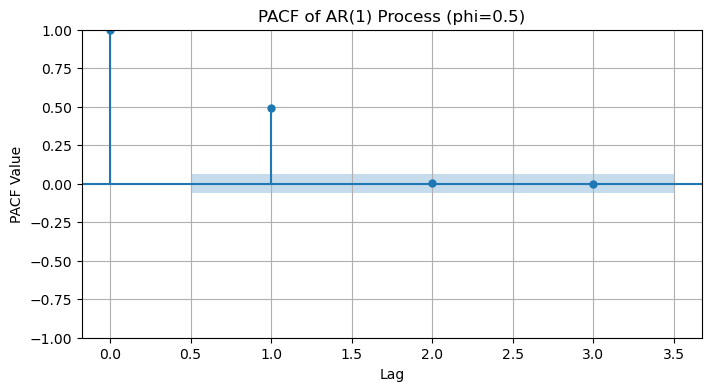

In [3]:
# PACF AR(1)

import numpy as np
from statsmodels.tsa.stattools import pacf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Define the parameters for the AR(1) process
phi = 0.5 # Autoregressive parameter
n_samples = 1000 # Number of data points to simulate

# 1. Simulate the AR(1) process: X_t = 0.5 * X_{t-1} + W_t
# Generate white noise (Wt)
np.random.seed(42) # Set seed for reproducibility
white_noise = np.random.normal(0, 1, n_samples)
X = np.zeros(n_samples)

# Apply the AR(1) formula iteratively
for t in range(1, n_samples):
    X[t] = phi * X[t-1] + white_noise[t]

# 2. Calculate the PACF for the simulated data
# Specify 'yw' (Yule-Walker) method, a common choice for PACF
# include_lag0=True adds the lag 0 value, which is always 1
pacf_values = pacf(X, nlags=3, method='yw')

# 3. Print the calculated PACF values for lags 0, 1, 2, and 3
print(f"PACF values for phi = {phi}:")
for lag, value in enumerate(pacf_values):
    print(f"Lag {lag}: {value:.4f}")

# 4. (Optional) Plot the PACF
# The plot visually confirms that only lag 1 is significant for an AR(1) process
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(X, lags=3, ax=ax, method='yw', title='PACF of AR(1) Process (phi=0.5)')
plt.xlabel('Lag')
plt.ylabel('PACF Value')
plt.grid(True)
plt.show()


In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Vikihyaat Ahlawat\CO2.csv", header=54)

# Select all rows starting from index 2 (the third row) to the end
df_truncated = df.iloc[2:]
# Assuming 'df' is your DataFrame
current_name = df_truncated.columns[4]
print(f"The current fifth column name is: {current_name}")

# Now rename it
df_truncated = df_truncated.rename(columns={current_name: 'CO2'})
print(df_truncated.columns)

# View the result
print(df_truncated.head())
t = [(i + 0.5) / 12 for i in range(len(df_truncated['CO2']))]
df_truncated['t']=t
df_truncated['CO2'] = pd.to_numeric(df_truncated['CO2'], errors='coerce')
df_truncated[' Mn'] = pd.to_numeric(df_truncated[' Mn'], errors='coerce')

# Replace all instances of -99.99 with NaN
df_replaced = df_truncated.replace(-99.99, pd.NA)

# Now drop the rows containing these standard missing values
df_final = df_replaced.dropna()

df_final.head()

The current fifth column name is:      CO2
Index(['  Yr', ' Mn', '    Date', '      Date', 'CO2', 'seasonally',
       '        fit', '  seasonally', '      CO2', ' seasonally'],
      dtype='object')
     Yr   Mn      Date        Date        CO2 seasonally          fit  \
2  1958   01     21200   1958.0411     -99.99     -99.99       -99.99   
3  1958   02     21231   1958.1260     -99.99     -99.99       -99.99   
4  1958   03     21259   1958.2027     315.70     314.43       316.19   
5  1958   04     21290   1958.2877     317.45     315.16       317.30   
6  1958   05     21320   1958.3699     317.51     314.71       317.86   

    seasonally          CO2  seasonally  
2       -99.99       -99.99      -99.99  
3       -99.99       -99.99      -99.99  
4       314.90       315.70      314.43  
5       314.98       317.45      315.16  
6       315.06       317.51      314.71  


,Yr,Mn,Date,Date,CO2,seasonally,fit,seasonally,CO2,seasonally,t
4,1958,3,21259,1958.2027,315.7,314.43,316.19,314.90,315.70,314.43,0.208333
5,1958,4,21290,1958.2877,317.45,315.16,317.30,314.98,317.45,315.16,0.291667
6,1958,5,21320,1958.3699,317.51,314.71,317.86,315.06,317.51,314.71,0.375000
8,1958,7,21381,1958.5370,315.86,315.19,315.86,315.21,315.86,315.19,0.541667
9,1958,8,21412,1958.6219,314.93,316.19,313.99,315.29,314.93,316.19,0.625000


In [6]:
train_test_split = int(len(df_final['CO2']) * 0.8)
train_CO2, test_CO2 = df_final['CO2'][:train_test_split], df_final['CO2'][train_test_split:]
train_date,test_date = df_final['t'][:train_test_split], df_final['t'][train_test_split:]

print(train_CO2)
print(df_final)
     
train_date, test_date = df_final['t'][:train_test_split], df_final['t'][train_test_split:]
assert(len(train_date) + len(test_date) == len(df_final['t']))


4       315.7
5      317.45
6      317.51
8      315.86
9      314.93
        ...  
591    383.71
592    384.34
593    386.23
594    386.41
595    385.87
Name: CO2, Length: 587, dtype: object
       Yr   Mn      Date        Date     CO2 seasonally          fit  \
4    1958    3     21259   1958.2027   315.7     314.43       316.19   
5    1958    4     21290   1958.2877  317.45     315.16       317.30   
6    1958    5     21320   1958.3699  317.51     314.71       317.86   
8    1958    7     21381   1958.5370  315.86     315.19       315.86   
9    1958    8     21412   1958.6219  314.93     316.19       313.99   
..    ...  ...       ...         ...     ...        ...          ...   
738  2019    5     43600   2019.3699  414.83     411.42       414.53   
739  2019    6     43631   2019.4548  413.96     411.38       413.89   
740  2019    7     43661   2019.5370  411.85     411.03       412.32   
741  2019    8     43692   2019.6219  410.08     411.62       410.17   
742  2019    9  

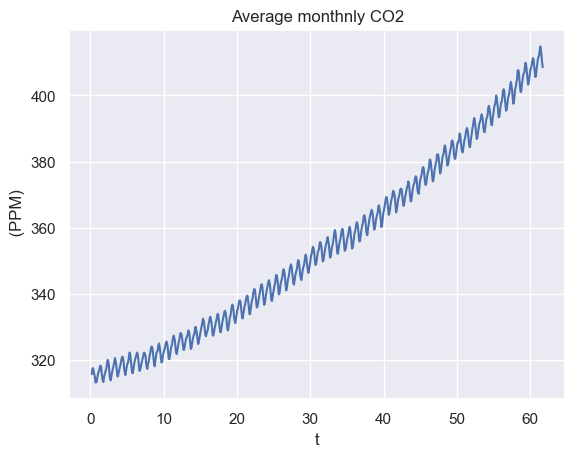

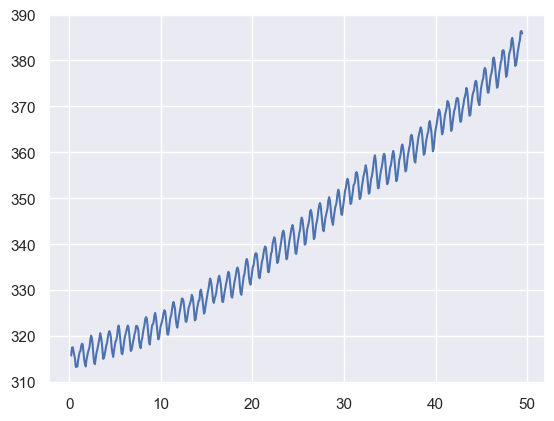

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()


time = df_final.t.values.reshape(-1,1)
CO2_level = df_final.CO2.values.reshape(-1,1)
sns.lineplot(x=df_final.t, y=df_final.CO2)
plt.title("Average monthnly CO2")
plt.ylabel(' (PPM)')
plt.show()

plt.plot(train_date,train_CO2)

[[1.40669115]]
[308.99165673]


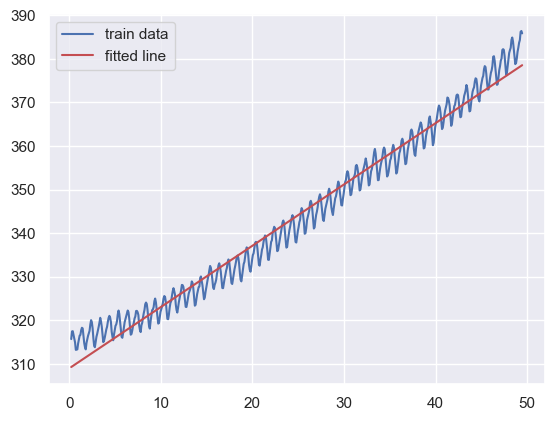

In [8]:
from sklearn import linear_model
clf = linear_model.LinearRegression()
clf.fit(train_date.values.reshape(-1,1), train_CO2.values.reshape(-1,1))
print(clf.coef_)
print(clf.intercept_)
# Print the beta values found via regression 
y_hat = clf.predict(train_date.values.reshape(-1,1))
plt.plot(train_date, train_CO2, label='train data')
plt.plot(train_date, y_hat, 'r', label='fitted line')
plt.legend()

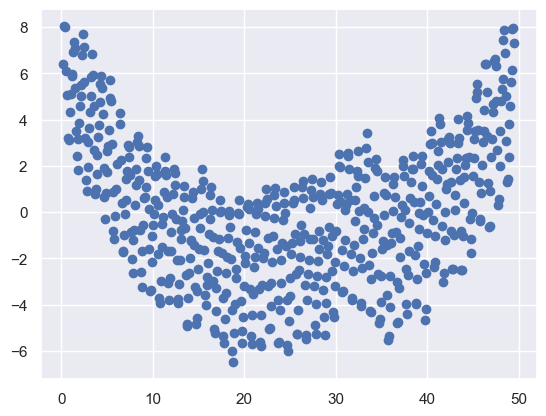

In [9]:
linear_residuals = train_CO2.values.reshape(-1,1) - y_hat
plt.plot(train_date, linear_residuals,'o')

In [10]:
from sklearn.metrics import mean_squared_error,mean_absolute_percentage_error
y_hat = clf.predict(test_date.values.reshape(-1,1))
print(np.sqrt(mean_squared_error(test_CO2, y_hat)))
print(mean_absolute_percentage_error(test_CO2, y_hat))

10.6414585218747
0.024504549564431502


[[0.80209702 0.0121175 ]]
[314.10058419]


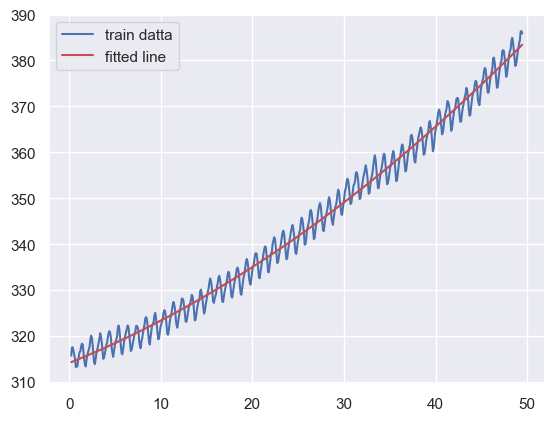

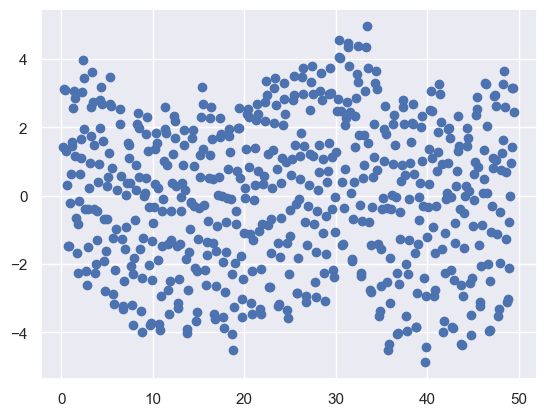

RMSE with quadratic fit: 2.1881157330174426
2.5013322194897865
0.005320319129740861


In [11]:
index_train=train_date.values.reshape(-1,1)
index_test=test_date.values.reshape(-1,1)
new_x = np.hstack((index_train, index_train**2))
new_x_test=np.hstack((index_test, index_test**2))
clf.fit(new_x, train_CO2.values.reshape(-1,1))
print(clf.coef_) # To print the coefficient estimate of the series.
print(clf.intercept_)
quad_prediction = clf.predict(new_x)
plt.plot(index_train, train_CO2, label='train datta')
plt.plot(index_train, quad_prediction, 'r', label='fitted line')
plt.legend()
plt.show()
quad_residuals = train_CO2.values.reshape(-1,1) - quad_prediction
plt.plot(index_train, quad_residuals, 'o')
plt.show();
print("RMSE with quadratic fit:", np.sqrt(np.mean((quad_residuals)**2)))

y_hat = clf.predict(new_x_test)
print(np.sqrt(mean_squared_error(test_CO2, y_hat)))
print(mean_absolute_percentage_error(test_CO2, y_hat))


[[ 6.24895409e-01  2.09575674e-02 -1.18323397e-04]]
[314.85852616]


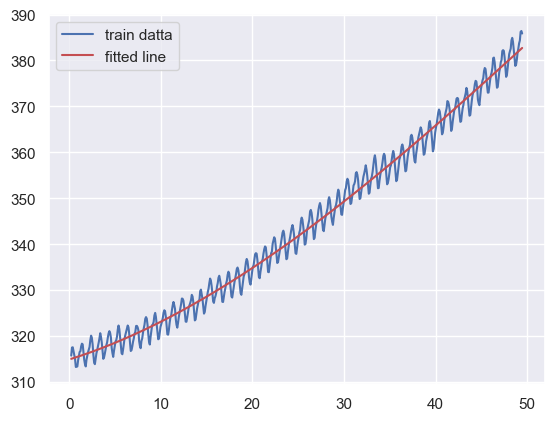

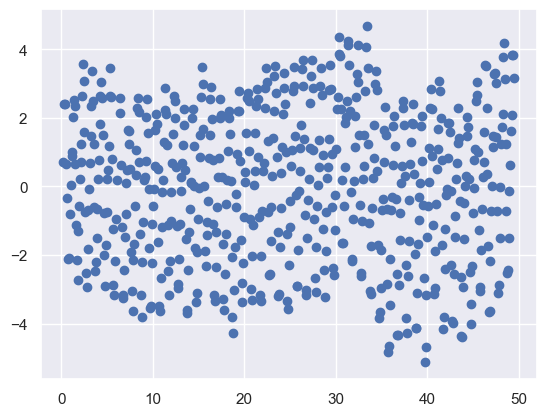

RMSE with cubic fit: 2.171766686567769
4.149370712135022
0.008483502723897751


In [12]:
index_train=train_date.values.reshape(-1,1)
index_test=test_date.values.reshape(-1,1)
new_x_cubic = np.hstack((new_x,index_train**3))
new_x_cubic_test=np.hstack((new_x_test,index_test**3))
clf.fit(new_x_cubic, train_CO2.values.reshape(-1,1))
print(clf.coef_) # To print the coefficient estimate of the series.
print(clf.intercept_)
cubic_prediction = clf.predict(new_x_cubic)
plt.plot(index_train, train_CO2, label='train datta')
plt.plot(index_train, cubic_prediction, 'r', label='fitted line')
plt.legend()
plt.show()
cubic_residuals = train_CO2.values.reshape(-1,1) - cubic_prediction
plt.plot(index_train, cubic_residuals, 'o')
plt.show();
print("RMSE with cubic fit:", np.sqrt(np.mean((cubic_residuals)**2)))

y_hat = clf.predict(new_x_cubic_test)
print(np.sqrt(mean_squared_error(test_CO2, y_hat)))
print(mean_absolute_percentage_error(test_CO2, y_hat))
# cubic fit did not improve mean dsquared error and residuals and therefore quadratic fit is the best option.

[[0.80209702 0.0121175 ]]
[314.10058419]


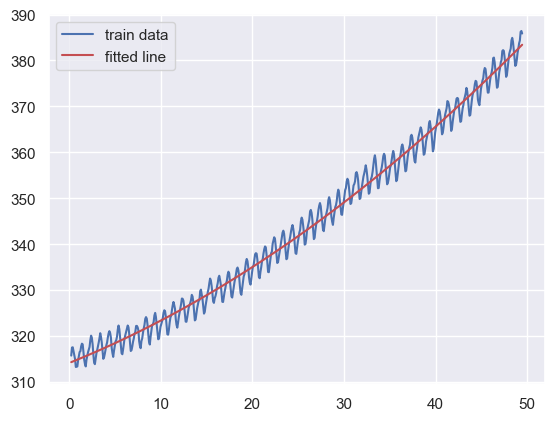

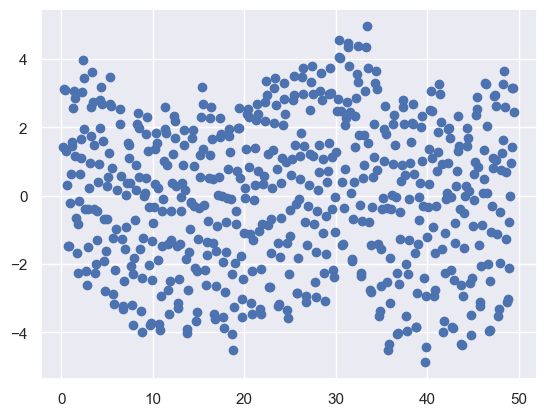

RMSE with quadratic fit: 2.1881157330174426
2.5013322194897865
0.005320319129740861


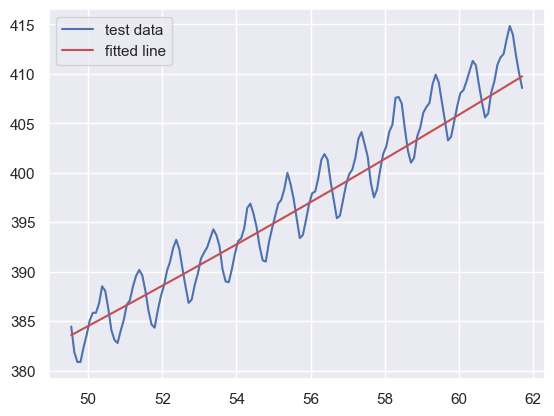

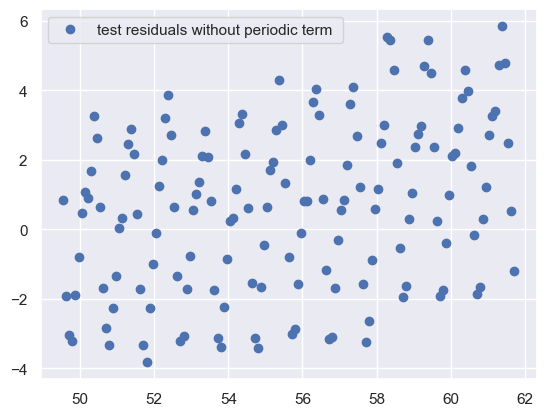

In [32]:
index_train=train_date.values.reshape(-1,1)
index_test=test_date.values.reshape(-1,1)
new_x = np.hstack((index_train, index_train**2))
new_x_test=np.hstack((index_test, index_test**2))
clf.fit(new_x, train_CO2.values.reshape(-1,1))
print(clf.coef_) # To print the coefficient estimate of the series.
print(clf.intercept_)
quad_prediction = clf.predict(new_x)
plt.plot(index_train, train_CO2, label='train data')
plt.plot(index_train, quad_prediction, 'r', label='fitted line')
plt.legend()
plt.show()
quad_residuals = train_CO2.values.reshape(-1,1) - quad_prediction
plt.plot(index_train, quad_residuals, 'o')
plt.show();
print("RMSE with quadratic fit:", np.sqrt(np.mean((quad_residuals)**2)))

y_hat = clf.predict(new_x_test)
print(np.sqrt(mean_squared_error(test_CO2, y_hat)))
print(mean_absolute_percentage_error(test_CO2, y_hat))

plt.plot(index_test, test_CO2, label='test data')
plt.plot(index_test, y_hat, 'r', label='fitted line')
plt.legend()
plt.show()
quad_residuals = test_CO2.values.reshape(-1,1) - y_hat
plt.plot(index_test, quad_residuals, 'o', label = 'test residuals without periodic term ')
plt.legend()
plt.show();

In [14]:
quad_prediction = clf.predict(new_x)

quad_residuals = train_CO2.values.reshape(-1,1) - quad_prediction
 
df_train = pd.DataFrame(train_CO2.values.reshape(-1,1), columns=['CO2'])
df_train[['Resi']]=quad_residuals
df_train[['Mn']] = train_date.values.reshape(-1,1)
Month_train=df_final[' Mn'][:train_test_split]
df_train[['Month']] = Month_train.values.reshape(-1,1)
print(df_train.head())



# Group by the 'months' column and calculate the sum of 'value' for each month
grouped_by_month = df_train.groupby('Month')['Resi'].mean().round(3)

print(grouped_by_month)

      CO2      Resi        Mn  Month
0   315.7  1.431786  0.208333      3
1  317.45   3.11444  0.291667      4
2  317.51  3.106925  0.375000      5
3  315.86  1.321391  0.541667      7
4  314.93  0.323372  0.625000      8
Month
1    -0.012919
2     0.646407
3     1.355569
4     2.561858
5     2.982891
6     2.316473
7     0.776297
8    -1.301213
9    -3.128074
10    -3.30952
11   -2.081487
12   -0.921507
Name: Resi, dtype: object


Month
1   -0.012919
2    0.646407
3    1.355569
4    2.561858
5    2.982891
Name: Resi, dtype: object
[ 1  2  3  4  5  6  7  8  9 10 11 12]


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_16232\1514591736.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Periodic_Signal_Pi'] = df_final[' Mn'].apply(P_i_func)
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_16232\1514591736.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['prediction']=clf.predict(x)
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_16232\1514591736.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

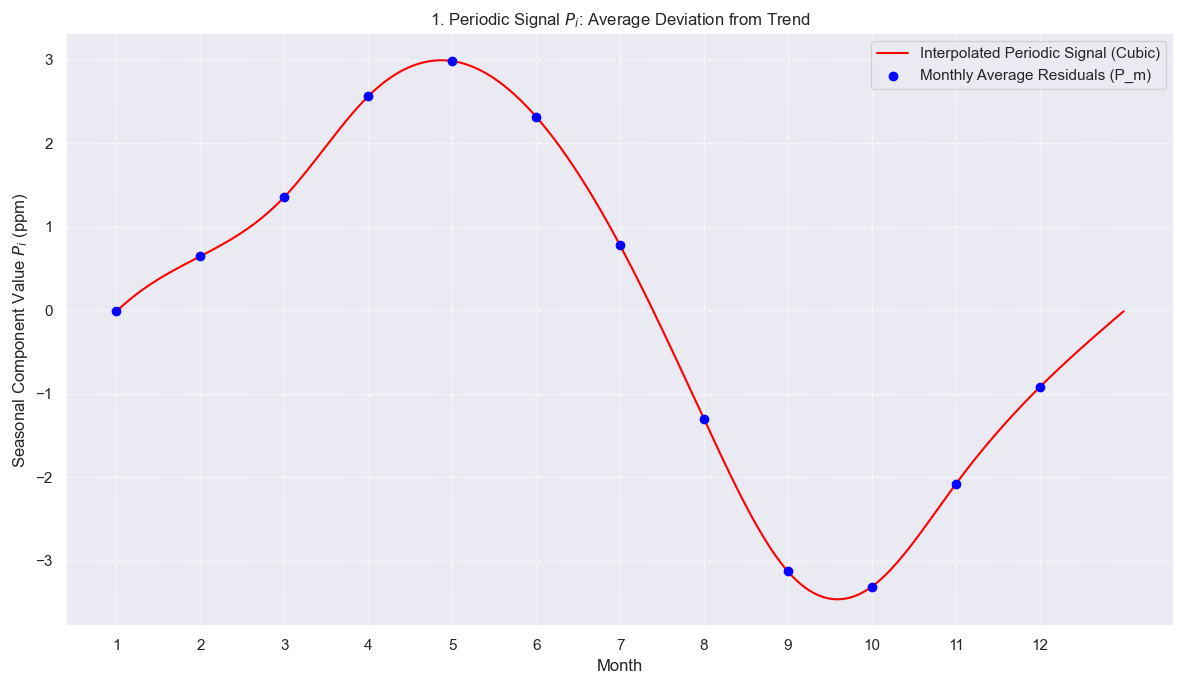

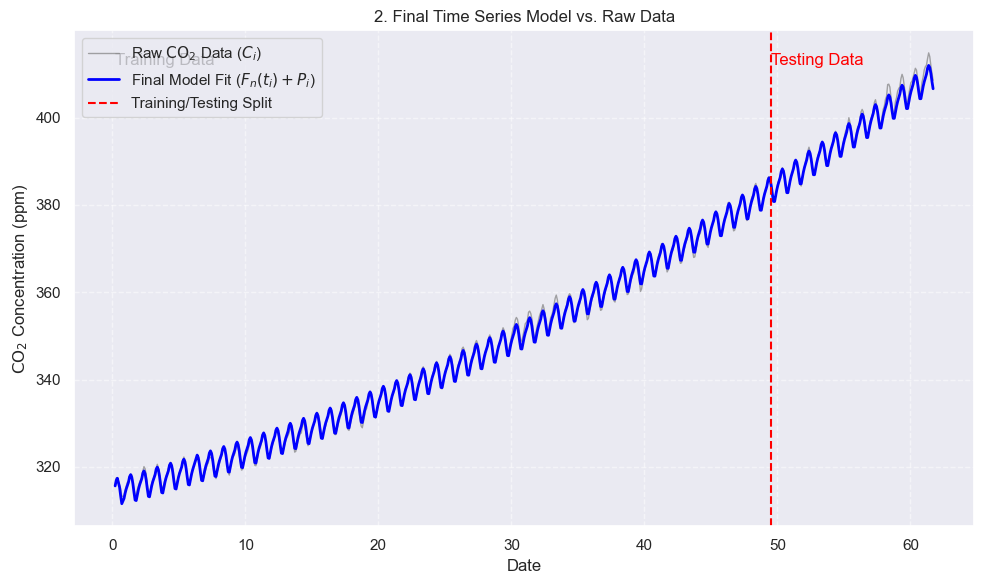

In [42]:
from datetime import date
from scipy.interpolate import interp1d
periodic_signal_train = df_train.groupby('Month')['Resi'].mean().round(3)

print(periodic_signal_train.head())
# Prepare data for interpolation
# The average residual P_m is calculated for months 1 through 12.
monthly_indices = periodic_signal_train.index
Month_index = [int(item) for item in monthly_indices]
month_index=np.array(Month_index)
periodic_values = periodic_signal_train.values
print(month_index)
# To make the signal periodic for interpolation, we append the first point (Jan) to the end (Month 13)
# This allows the interpolation to wrap around smoothly
monthly_indices_wrapped = np.append(month_index, month_index[0] + 12)
periodic_values_wrapped = np.append(periodic_values, periodic_values[0])

# Define the periodic signal P_i(t) as an interpolation function
# 'cubic' interpolation is often used for smooth periodic functions
P_i_func = interp1d(monthly_indices_wrapped, periodic_values_wrapped, kind='cubic')


# --- 5. CALCULATE FINAL MODEL FIT (F_n(t) + P_i) ---

# Apply the periodic signal function P_i(t) to the month number of each data point
df_final['Periodic_Signal_Pi'] = df_final[' Mn'].apply(P_i_func)
index=df_final['t'].values.reshape(-1,1)
x = np.hstack((index, index**2))
df_final['prediction']=clf.predict(x)
# Final model fit C_model(t) = F_n(t) + P_i(t)
df_final['Final_Fit'] = df_final['Periodic_Signal_Pi'] + df_final['prediction']


# --- 6. PLOTTING ---

# Plot 1: Periodic Signal P_i
plt.figure(figsize=(12, 7))
# Interpolated curve (P_i)
x_interp = np.linspace(1, 13, 300)
y_interp = P_i_func(x_interp)
plt.plot(x_interp, y_interp, label='Interpolated Periodic Signal (Cubic)', color='red')
# 12 monthly data points (P_m)
plt.scatter(monthly_indices, periodic_values, label='Monthly Average Residuals (P_m)', color='blue', zorder=5)

plt.title(r'1. Periodic Signal $P_i$: Average Deviation from Trend')
plt.xlabel('Month')
plt.ylabel(r'Seasonal Component Value $P_i$ (ppm)')
plt.xticks(np.arange(1, 13), periodic_signal_train.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('period.png')
plt.show() # Display Plot 1

# Plot 2: Final Fit F_n(t_i) + P_i
plt.figure(figsize=(10, 6))

# Raw Data (C_i)
plt.plot(df_final['t'], df_final['CO2'], label=r'Raw $\text{CO}_2$ Data ($C_i$)', color='gray', linewidth=1, alpha=0.7)

# Final Model Fit (F_n(t_i) + P_i)
plt.plot(df_final['t'], df_final['Final_Fit'], label=r'Final Model Fit ($F_n(t_i) + P_i$)', color='blue', linewidth=2)

# Training/Testing Split Line
split_date = df_final['t'].iloc[train_test_split]
plt.axvline(x=split_date, color='red', linestyle='--', label=f'Training/Testing Split')
plt.text(split_date, df_final['CO2'].max(), 'Testing Data', rotation=0, verticalalignment='top', color='red')
plt.text(df_final['t'].iloc[0], df_final['CO2'].max(), 'Training Data', rotation=0, verticalalignment='top', color='black')

plt.title(r'2. Final Time Series Model vs. Raw Data')
plt.xlabel('Date')
plt.ylabel(r'$\text{CO}_2$ Concentration (ppm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('final.png')
plt.show() # Display Plot 2



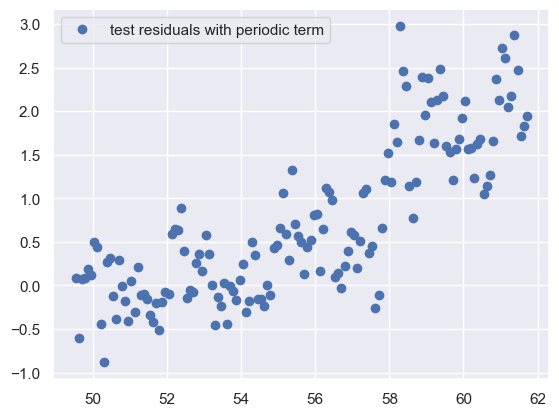

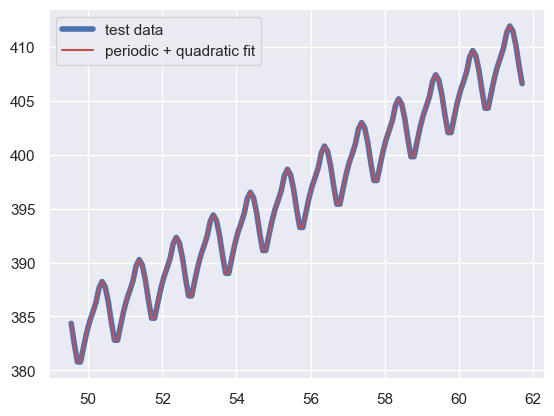

RMSE with quadratic fit: 1.1493602690794478
1.1493602690794475
0.0020859165947991125


In [58]:
df_test = pd.DataFrame()
df_test['Periodic_Signal_Pi'] = df_final[' Mn'][train_test_split:].apply(P_i_func)
index_test=df_final['t'][train_test_split:].values.reshape(-1,1)
x = np.hstack((index_test, index_test**2))
df_test['prediction']=clf.predict(x)
# Final model fit C_model(t) = F_n(t) + P_i(t)
df_test['Final_Fit'] = df_test['Periodic_Signal_Pi'] + df_test['prediction']
residuals = test_CO2.values - df_test['Final_Fit'].values
plt.plot(index_test, residuals, 'o', label = 'test residuals with periodic term')
plt.legend()
plt.show();
plt.plot(index_test, df_test['Final_Fit'].values,linewidth = 4, label = 'test data')
plt.plot(index_test, df_test['Final_Fit'].values, 'r', label = 'periodic + quadratic fit')
plt.legend()
plt.show();
print("RMSE with quadratic fit:", np.sqrt(np.mean((residuals)**2)))


print(np.sqrt(mean_squared_error(test_CO2, df_test['Final_Fit'])))
print(mean_absolute_percentage_error(test_CO2, df_test['Final_Fit']))

In [21]:
print("--- ANALYSIS OF VARIATION DECOMPOSITION (Q4) ---")

# Calculate components for Q4
# 1. Range of F_n(t) on the entire dataset
range_F = df_final['prediction'].max() - df_final['prediction'].min()

# 2. Amplitude of P_i (Half of the peak-to-peak range)
range_Pi = df_final['Periodic_Signal_Pi'].max() - df_final['Periodic_Signal_Pi'].min()
amplitude_Pi = range_Pi

# 3. Range of the residual R_i (C_i - Final_Fit)
final_residual = df_final['CO2'] - df_final['Final_Fit']
range_Ri = final_residual.max() - final_residual.min()

# Calculate Ratios
ratio_F_to_Pi_amplitude = range_F / amplitude_Pi
ratio_Pi_amplitude_to_Ri_range = amplitude_Pi / range_Ri

print(f"\nRange of Trend (F): {range_F:.3f} ppm")
print(f"Amplitude of Periodic Signal (P_i): {amplitude_Pi:.3f} ppm")
print(f"Range of Final Residual (R_i): {range_Ri:.3f} ppm")

print(f"\nRatio 1 (Range of F / Amplitude of P_i): {ratio_F_to_Pi_amplitude:.3f}")
print(f"Ratio 2 (Amplitude of P_i / Range of R_i): {ratio_Pi_amplitude_to_Ri_range:.3f}")

# --- Q4 Discussion ---
print("\n[Q4 Discussion]")
q4_discussion = f"""
The first ratio (Range of $F$ / Amplitude of $P_i$) is {ratio_F_to_Pi_amplitude:.3f}. Since this value is significantly greater than 1, it indicates that the long-term, **deterministic trend ($F_n(t)$) dominates the overall variation** of the $\\text{{CO}}_2$ data over the period studied. The trend accounts for approximately {ratio_F_to_Pi_amplitude:.0f} times the magnitude of the seasonal variation.

The second ratio (Amplitude of $P_i$ / Range of Residual $R_i$) is {ratio_Pi_amplitude_to_Ri_range:.3f}. Since this ratio is greater than 1, the **periodic signal ($P_i$) is the dominant source of short-term variation** compared to the remaining random noise ($R_i$). Specifically, the seasonal cycle is about {ratio_Pi_amplitude_to_Ri_range:.0f} times smaller than the range of the unmodeled error.

**Conclusion on Meaningfulness:** This decomposition is **highly meaningful**. It successfully partitions the total variation into three distinct, important components: a dominant long-term increase (Trend $F$), a strong, predictable annual cycle (Periodic Signal $P_i$), and a small, relatively insignificant random error (Residual $R_i$). The high value of the second ratio confirms that the chosen periodic component has successfully extracted the major deterministic fluctuation from the residuals, leaving very little unmodeled structure.
"""
print(q4_discussion)
print("="*70)

--- ANALYSIS OF VARIATION DECOMPOSITION (Q4) ---

Range of Trend (F): 95.471 ppm
Amplitude of Periodic Signal (P_i): 6.292 ppm
Range of Final Residual (R_i): 4.716 ppm

Ratio 1 (Range of F / Amplitude of P_i): 15.172
Ratio 2 (Amplitude of P_i / Range of R_i): 1.334

[Q4 Discussion]

The first ratio (Range of $F$ / Amplitude of $P_i$) is 15.172. Since this value is significantly greater than 1, it indicates that the long-term, **deterministic trend ($F_n(t)$) dominates the overall variation** of the $\text{CO}_2$ data over the period studied. The trend accounts for approximately 15 times the magnitude of the seasonal variation.

The second ratio (Amplitude of $P_i$ / Range of Residual $R_i$) is 1.334. Since this ratio is greater than 1, the **periodic signal ($P_i$) is the dominant source of short-term variation** compared to the remaining random noise ($R_i$). Specifically, the seasonal cycle is about 1 times smaller than the range of the unmodeled error.

**Conclusion on Meaningfulnes

In [131]:
import pandas as pd

df_CPI = pd.read_csv(r'C:\Users\Vikihyaat Ahlawat\CPI.csv')
df_CPI = df_CPI.dropna()
df_CPI.tail()

,date,CPI
4082,9/27/2019,117.2488
4083,9/28/2019,117.2488
4084,9/29/2019,117.2488
4085,9/30/2019,117.2488
4086,10/1/2019,117.3407


In [135]:
# Convert the 'Date_Column' to datetime objects
df_CPI['Date_Column'] = pd.to_datetime(df_CPI['date'])
df_daily = pd.DataFrame(df_CPI).set_index('Date_Column')
df_monthly = df_daily['CPI'].resample('MS').mean()
print(df_monthly)

Date_Column
2008-07-01    100.00000
2008-08-01    100.52510
2008-09-01    100.12380
2008-10-01     99.98538
2008-11-01     98.97539
                ...    
2019-06-01    117.03590
2019-07-01    117.05920
2019-08-01    117.25480
2019-09-01    117.24880
2019-10-01    117.34070
Freq: MS, Name: CPI, Length: 136, dtype: float64


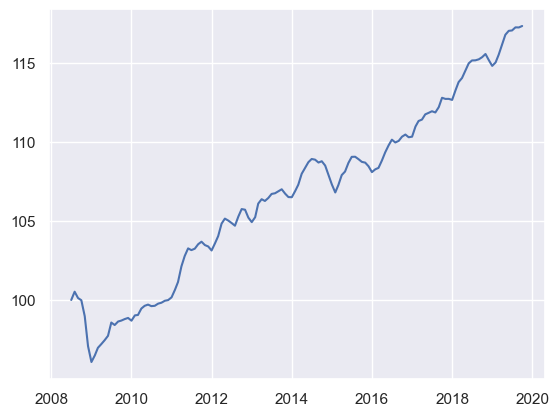

In [137]:
plt.plot(df_monthly)
plt.show()

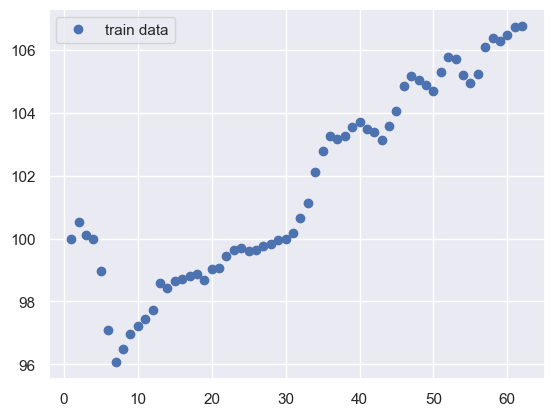

In [140]:
index =df_monthly.index


# Define the target datetime
target_datetime = pd.Timestamp('2013-09-01')

# Select the series with index values less than the target datetime
train_series = df_monthly[df_monthly.index < target_datetime]
test_series = df_monthly[df_monthly.index >= target_datetime]


train_series.index= list(range(1,len(train_series) +1))
test_series.index=  list(range(len(train_series) +1,len(df_monthly)+1))

plt.plot(train_series, 'o', label ="train data")
plt.legend()
plt.show()

In [142]:
from sklearn import linear_model
clf = linear_model.LinearRegression()
x=train_series.index.values.reshape(-1,1)
clf.fit(x,train_series)
print(clf.coef_) # Print the beta values found via regression 
print(clf.intercept_)
y=clf.predict(x)


[0.16104348]
96.5682828450555


-3.63473018760547


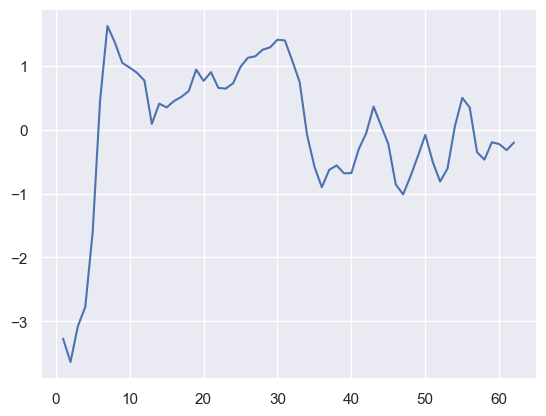

In [144]:
Residuals =  y- train_series
print(max(Residuals,key=abs))
plt.plot(Residuals)
plt.show()

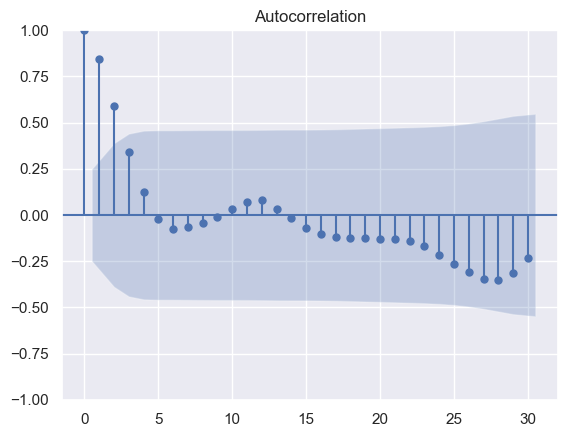

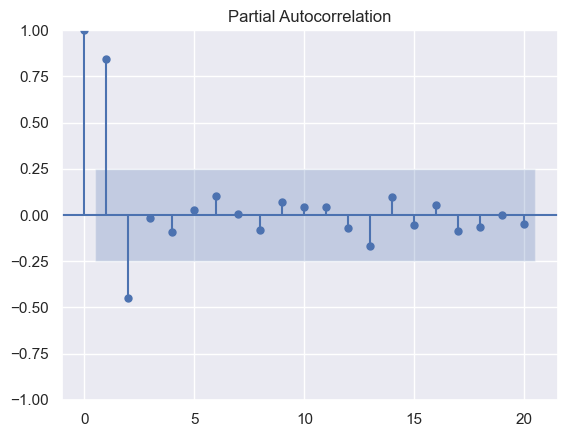

In [146]:
import statsmodels.api as sm
sm.graphics.tsa.plot_acf(Residuals, lags=30)
plt.show()

sm.graphics.tsa.plot_pacf(Residuals, lags=20)
plt.show()

In [148]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
AR_ORDER = 2
# --- B. Fit the AR(p) Model to the residuals (epsilon_t) ---
# We fit the AR(p) model to the residuals, as the problem states the model is
# a sum of the linear trend and the AR(p) process on the de-trended data.
# Note: statsmodels AR model takes the time series data directly.
ar_model = AutoReg(Residuals, lags=AR_ORDER, trend='c' ) # 'n' for no trend and c for for a contant intercept, 
ar_model_fit = ar_model.fit()

# Extracted AR Parameters from Training
ar_coefs = ar_model_fit.params

print(f"AR({AR_ORDER}) Coefficients (phi): {ar_coefs.values}\n")



AR(2) Coefficients (phi): [ 0.04310485  1.32366553 -0.5307974 ]



D:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [150]:
# --- 3. 1-Month-Ahead Rolling Forecast for Validation Data ---
all_data_series = df_monthly
all_data_series.index =list(range(1,len(df_monthly) +1))
actual_cpi_validation = test_series.values
forecasts = []

# We need the full time series to compute the AR part of the forecast,
# as it uses the *actual* data from the previous steps (Y_t-1, Y_t-2, etc.)
 

print("--- 1-Month-Ahead Rolling Forecast (Validation Period) ---")

# Iterate through each time step 't' in the validation period
for i in range(len(test_series)):
    time_index =all_data_series.index.get_loc(test_series.index[i]) # Current index
   

    # --- Step 1: Calculate the Trend part of the forecast (Tt) ---
    # The trend only depends on the time index 't'
    trend_forecast = clf.intercept_ + clf.coef_[0] * time_index

    # --- Step 2: Calculate the AR part of the forecast (Epsilon_t) ---
    # This is the recursive part. The AR model uses the previously observed actual CPI values.
    # The AR(p) model is fitted to the residuals: epsilon_t = phi1*epsilon_t-1 + ...
    # where epsilon_t-k = Y_t-k - T_t-k
    

    ar_forecast = ar_coefs[0]
    # Loop over the AR order (lags)
    for k in range(1, AR_ORDER + 1):
        phi_k = ar_coefs[k]
        
        # Index of the actual past data point to use (k steps back)
        past_index = time_index - k 

        # Check if the required past data exists (it should, as we use the full series)
        if past_index >= 0:
            # 1. Get the actual past CPI value (Y_t-k)
            Y_past = all_data_series.iloc[past_index]

            # 2. Calculate the Trend at that past time step (T_t-k)
            T_past = clf.intercept_ + clf.coef_[0] * past_index

            # 3. Calculate the actual past residual (Epsilon_t-k = Y_t-k - T_t-k)
            residual_past = Y_past - T_past

            # 4. Add to AR forecast sum: phi_k * Epsilon_t-k
            ar_forecast += phi_k * residual_past
        else:
            # This handles cases where we are forecasting the very first few points
            # and the lag goes before the training start date (typically handled by statsmodels)
            # For simplicity in this example, we assume past data is available.
            pass


    # --- Step 3: Combined Forecast ---
    # Final forecast is Tt + AR_forecast
    Y_hat_t = trend_forecast + ar_forecast 
    forecasts.append(Y_hat_t)


# --- 4. Calculate RMSE ---

forecasts = np.array(forecasts)

# Mean Squared Error (MSE)
mse = mean_squared_error(actual_cpi_validation, forecasts)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print("\n---------------------------------------------------")
print(f"Validation Period Length (n): {len(test_series)}")
print(f"Final Root Mean Squared Prediction Error (RMSE): {rmse:.4f}")
print("---------------------------------------------------")


--- 1-Month-Ahead Rolling Forecast (Validation Period) ---

---------------------------------------------------
Validation Period Length (n): 74
Final Root Mean Squared Prediction Error (RMSE): 0.4302
---------------------------------------------------


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\1776523012.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ar_forecast = ar_coefs[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\1776523012.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_k = ar_coefs[k]


In [153]:
# Convert the 'Date_Column' to datetime objects
df_CPI['Date_Column'] = pd.to_datetime(df_CPI['date'])
df_daily = pd.DataFrame(df_CPI).set_index('Date_Column')
df_monthly = df_daily['CPI'].resample('MS').mean()
print(df_monthly)

Date_Column
2008-07-01    100.00000
2008-08-01    100.52510
2008-09-01    100.12380
2008-10-01     99.98538
2008-11-01     98.97539
                ...    
2019-06-01    117.03590
2019-07-01    117.05920
2019-08-01    117.25480
2019-09-01    117.24880
2019-10-01    117.34070
Freq: MS, Name: CPI, Length: 136, dtype: float64


In [155]:
Monthly_rate = pd.Series(index=df_monthly.index, name = 'IR')

for i in range(len(Monthly_rate)):
    if i>0:
        Monthly_rate.iloc[i] =(df_monthly.iloc[i] - df_monthly.iloc[i-1])/df_monthly.iloc[i-1]
    else:
        Monthly_rate.iloc[0] = df_monthly.iloc[0]
 

for i in range(len(Monthly_rate)):
    if i>0:
        Monthly_rate.iloc[i] =(np.log(df_monthly.iloc[i]) - np.log(df_monthly.iloc[i-1]))
    else:
        Monthly_rate.iloc[0] = df_monthly.iloc[0]

print(Monthly_rate.loc['2013-02-01'])

0.002952865295193341


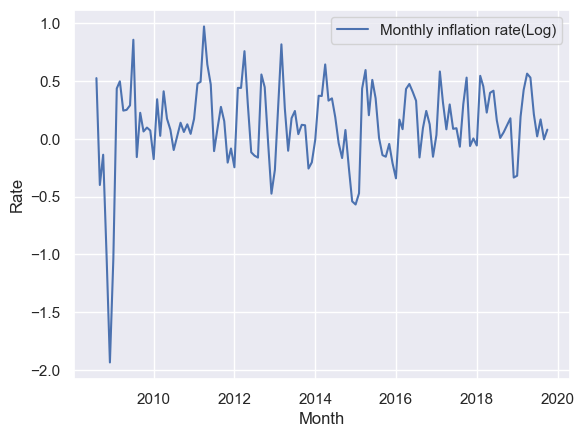

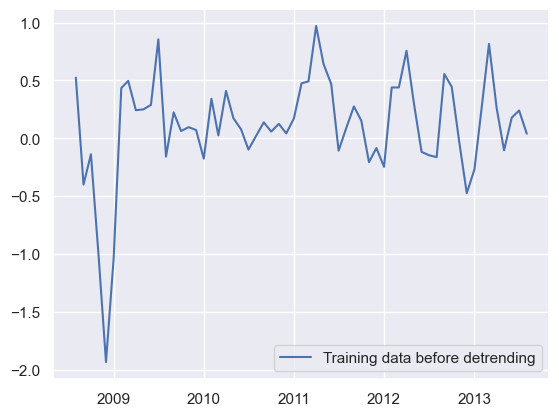

In [167]:
# plot monthly inflation rate
plt.plot(Monthly_rate[1:]*100, label= 'Monthly inflation rate(Log)')
plt.legend()
plt.xlabel('Month')
plt.ylabel('Rate')
plt.show()




[5.53001234e-05]
-0.0006980098468110474
0.01897242462364237


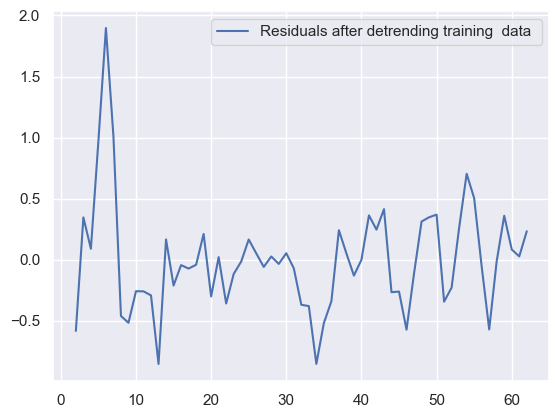

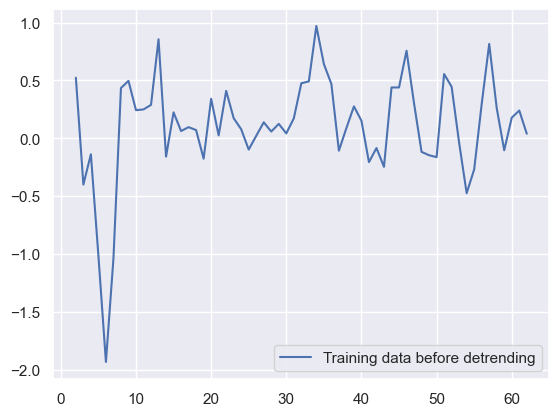

In [169]:

# Define the target datetime
target_datetime = '2013-09-01'

# Select the series with index values less than the target datetime
train_series = Monthly_rate[Monthly_rate.index < target_datetime]
test_series = Monthly_rate[Monthly_rate.index >= target_datetime]

train_series.index= list(range(1,len(train_series) +1))
test_series.index=  list(range(len(train_series) +1,len(df_monthly)+1))

clf = linear_model.LinearRegression()
x=train_series[1:].index.values.reshape(-1,1)
clf.fit(x,train_series[1:])
print(clf.coef_) # Print the beta values found via regression 
print(clf.intercept_)
y=clf.predict(x)



Residuals =  y- train_series[1:]
print(max(Residuals,key=abs))
plt.plot(x,Residuals*100, label='Residuals after detrending training  data ')
plt.legend()
plt.show()


plt.plot(train_series[1:]*100, label='Training data before detrending')
plt.legend()
plt.show()

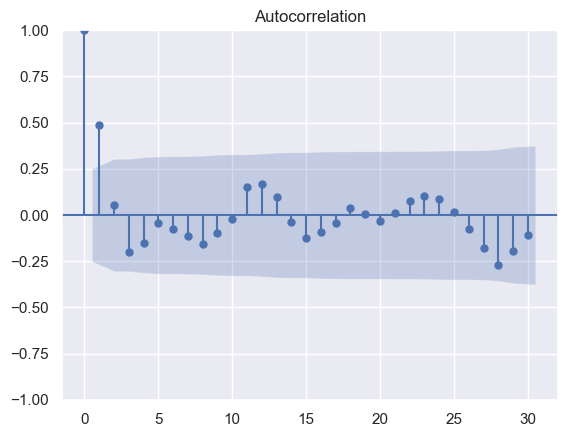

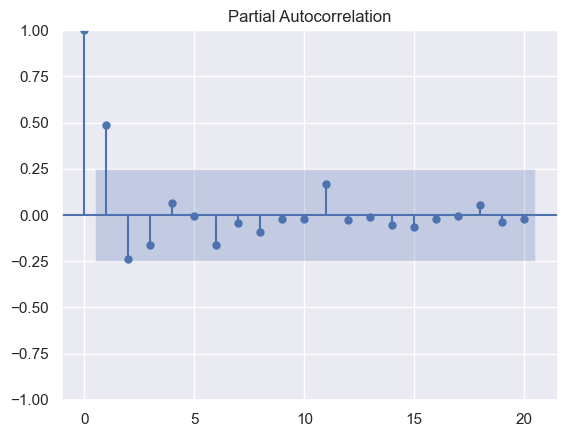

In [33]:
import statsmodels.api as sm
sm.graphics.tsa.plot_acf(Residuals, lags=30)
plt.show()

sm.graphics.tsa.plot_pacf(Residuals, lags=20)
plt.show()

D:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


AIC: -491.2554975421149
BIC: -484.9724638554486
Manual RMSE: 0.0038382668859176477


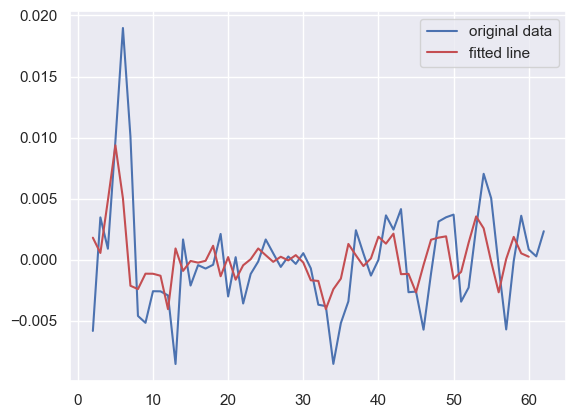

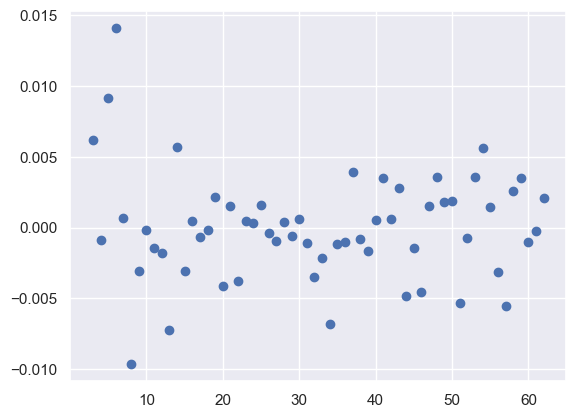

In [34]:
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error


# Fit the model
model = AutoReg(Residuals, lags=1, trend='c')
results = model.fit()
ar_predict=results.predict()
# Extract AIC and BIC
aic_value = results.aic
bic_value = results.bic

print(f"AIC: {aic_value}")
print(f"BIC: {bic_value}")


# Extract residuals
residuals = results.resid

# Calculate MSE manually
mse_manual = np.mean(residuals**2)

print(f"Manual RMSE: {np.sqrt(mse_manual)}")

plt.plot(Residuals, label='original data')
plt.plot(ar_predict, 'r', label='fitted line')
plt.legend()
plt.show()
plt.plot(residuals, 'o')
plt.show()


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\297706466.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\297706466.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\297706466.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc

## ✅Root Mean Squared Prediction Error (MSPE) for Validation Set:
RMSPE: 0.002451
--------------------------------------------------


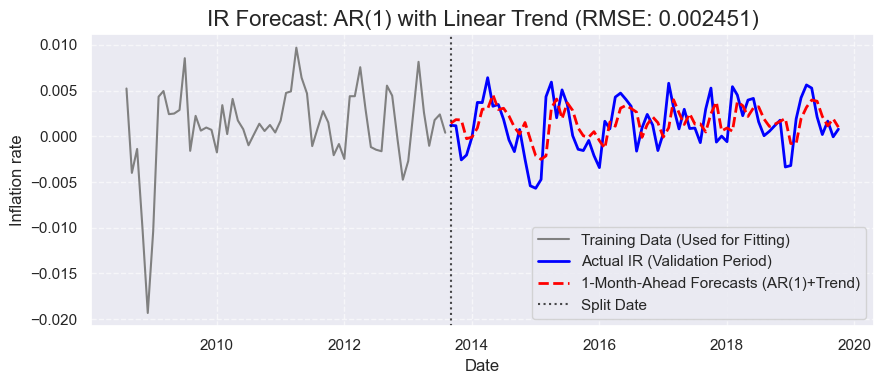

In [175]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
SPLIT_DATE="2013-09-01"
# ============================================================
# 2. TRAIN–TEST SPLIT
# ============================================================
start_eval = pd.to_datetime("2013-09-01")   # Begin 1-month-ahead evaluations
y_train_full = Monthly_rate[Monthly_rate.index < start_eval]      # Used initially for fitting
y_test = Monthly_rate[Monthly_rate.index >= start_eval]           # Forecast these months

# ============================================================
# 3. ROLLING 1-MONTH-AHEAD FORECAST WITH TREND + AR(1)
# ============================================================



forecasts = []

for date in y_test.index:

    # Use all data before the forecast month
    y_sub = Monthly_rate[Monthly_rate.index < date][1:]

    # Fit AutoReg(1,0,0) with linear trend
    model = AutoReg(y_sub, lags=1, trend='t').fit()

    # Forecast 1-step ahead
    y_hat = model.forecast(steps=1)[0]
    forecasts.append(y_hat)

forecast_series = pd.Series(forecasts, index=y_test.index)



# ============================================================
# 4. COMPUTE MEAN SQUARED PREDICTION ERROR
# ============================================================
mse = mean_squared_error(y_test.values, forecast_series.values)


print(f"## ✅Root Mean Squared Prediction Error (MSPE) for Validation Set:")
print(f"RMSPE: {np.sqrt(mse):.6f}")
print("-" * 50)
plt.figure(figsize=(9, 4))

# Plot Training Data
plt.plot(y_train_full[1:], label='Training Data (Used for Fitting)', color='gray', linestyle='-')

# Plot Validation Data (Actual)
plt.plot(forecast_series.index, y_test, label='Actual IR (Validation Period)', color='blue', linewidth=2)

# Plot Forecasts (Predictions)
plt.plot(forecast_series.index, forecast_series, label='1-Month-Ahead Forecasts (AR(1)+Trend)', color='red', linestyle='--', linewidth=2)

# Formatting
plt.title(f'IR Forecast: AR(1) with Linear Trend (RMSE: {np.sqrt(mse):.6f})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Inflation rate', fontsize=12)
plt.axvline(pd.to_datetime(SPLIT_DATE), color='black', linestyle=':', alpha=0.7, label='Split Date')
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('1 month_predict.png')

Testing AR(p) models for p=1 to p=5...


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.i

AR(1) RMSE: 0.0025


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.i

AR(2) RMSE: 0.0024


...

AR(3) RMSE: 0.0024


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.i

AR(4) RMSE: 0.0024


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\3726458970.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.i

AR(5) RMSE: 0.0025

Best AR model based on minimum RMSE is AR(2) with RMSE: 0.0024


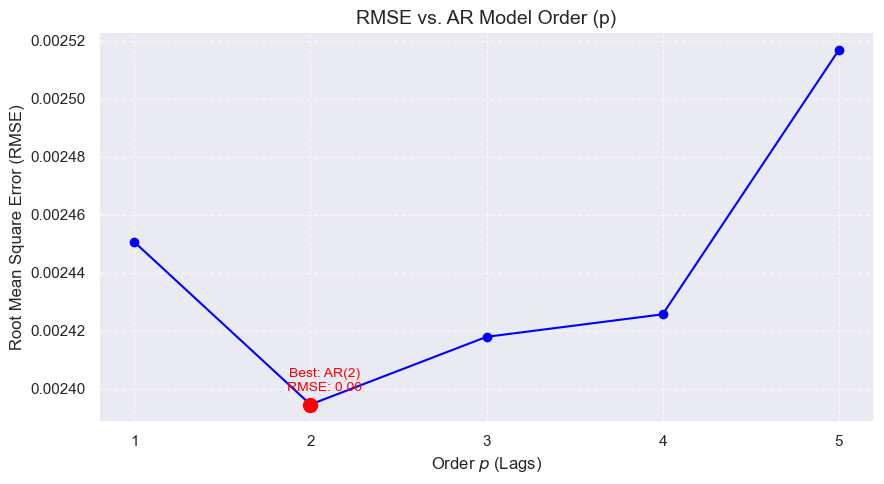

In [179]:
# --- 2. Iterate and Calculate RMSE for AR(p) Models ---
p_max = 5 # Maximum order (p) to test. Adjust this based on your PACF or preference.
rmse_values = {}

print(f"Testing AR(p) models for p=1 to p={p_max}...")

for p in range(1, p_max + 1):
    try:
        forecasts = []
        for date in y_test.index:
            # Use all data before the forecast month
            y_sub = Monthly_rate[Monthly_rate.index < date][1:]
            
            # Fit ARIMA(1,0,0) with linear trend
            # Note: order=(p,0,0) uses 'p' from the loop
            model = AutoReg(y_sub, lags=p, trend='t').fit()
            
            # Forecast 1-step ahead
            y_hat = model.forecast(steps=1)[0]
            forecasts.append(y_hat)
        
        # Calculate Root Mean Square Error (RMSE)
        # Ensure test_series is a 1D array of the same length as forecasts
        rmse = np.sqrt(mean_squared_error(test_series.values.reshape(-1,1), forecasts))
        rmse_values[p] = rmse
        print(f"AR({p}) RMSE: {rmse:.4f}")
    except Exception as e:
        print(f"Could not fit AR({p}): {e}")
        continue

# --- 3. Identify the Best Model ---
if rmse_values:
    best_p = min(rmse_values, key=rmse_values.get)
    best_rmse = rmse_values[best_p]
    print(f"\nBest AR model based on minimum RMSE is AR({best_p}) with RMSE: {best_rmse:.4f}")
    
    # --- 4. Plot RMSE vs. Lag (p) ---
    p_values = list(rmse_values.keys())
    rmse_list = list(rmse_values.values())
    
    plt.figure(figsize=(9, 5))
    plt.plot(p_values, rmse_list, marker='o', linestyle='-', color='blue')
    plt.title('RMSE vs. AR Model Order (p)', fontsize=14)
    plt.xlabel('Order $p$ (Lags)', fontsize=12)
    plt.ylabel('Root Mean Square Error (RMSE)', fontsize=12)
    plt.xticks(p_values)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Highlight the best model
    plt.scatter(best_p, best_rmse, color='red', s=100, zorder=5)
    plt.annotate(f'Best: AR({best_p})\nRMSE: {best_rmse:.2f}', 
                 (best_p, best_rmse), 
                 textcoords="offset points", 
                 xytext=(10, 10), 
                 ha='center', 
                 color='red', 
                 fontsize=10)
    
    plt.tight_layout()

plt.savefig('rmse_test versus lags.png') 

In [38]:
df = pd.read_csv('T10YIE.csv')

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE').sort_index()
df=df.dropna()
ber_series_daily = df['T10YIE']
print("Successfully loaded BER.csv and set 'Date' as index.")


# --- 2. Define Target Month and Filter Data ---

TARGET_MONTH = '2013-02'

# Filter for the target month (February 2013)
# We use .loc[] for easy slicing by date string
feb_2013_daily_ber = ber_series_daily.loc[TARGET_MONTH].dropna()

if feb_2013_daily_ber.empty:
    print(f"Error: No data found for the target month: {TARGET_MONTH}. Check your dataset range.")
else:
    # --- 3. Calculate Monthly Average BER (in percent) ---
    
    # "Use the average value of BER over each month as the monthly representative"
    monthly_representative_ber_percent = feb_2013_daily_ber.mean()
    
    # --- 4. Convert to Yearly Rate (BER_t^yearly) ---

    # "Since the data is given as percentages, you would need to first make a conversion."
    ber_yearly_rate = monthly_representative_ber_percent / 100
    
    # --- 5. Deannualize to Monthly Inflation Rate (BER_t^monthly) ---

    # Formula: BER_t^monthly = (BER_t^yearly + 1)^(1/12) - 1
    ber_monthly_rate = (ber_yearly_rate + 1)**(1/12) - 1
    
    # Convert the result back to a percentage for reporting
    monthly_inflation_rate_percent = ber_monthly_rate * 100
    
    # --- 6. Report the Result ---
    
    print("-" * 50)
    print(f"## 📈 Monthly Inflation Rate for {TARGET_MONTH}")
    print(f"1. Average Daily BER for Feb 2013 (in %): {monthly_representative_ber_percent:.4f}%")
    print(f"2. Yearly BER Rate (BER^yearly): {ber_yearly_rate:.6f}")
    print(f"3. Deannualized Monthly Rate (BER^monthly): {ber_monthly_rate:.6f}")
    print(f"--------------------------------------------------")
    print(f"   Monthly Inflation Rate for Feb 2013: {monthly_inflation_rate_percent:.4f}%")
    print("-" * 50)




Successfully loaded BER.csv and set 'Date' as index.
--------------------------------------------------
## 📈 Monthly Inflation Rate for 2013-02
1. Average Daily BER for Feb 2013 (in %): 2.5547%
2. Yearly BER Rate (BER^yearly): 0.025547
3. Deannualized Monthly Rate (BER^monthly): 0.002104
--------------------------------------------------
   Monthly Inflation Rate for Feb 2013: 0.2104%
--------------------------------------------------


C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\101544041.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\101544041.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1)[0]
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\101544041.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc

## ✅Root Mean Squared Prediction Error (MSPE) for Validation Set:
RMSPE: 0.0852
--------------------------------------------------


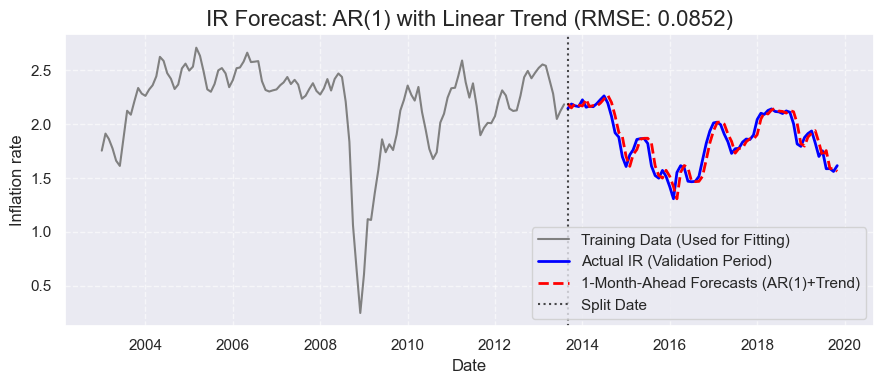

In [39]:
df_monthly = ber_series_daily.resample('MS').mean()
SPLIT_DATE="2013-09-01"
# ============================================================
# 2. TRAIN–TEST SPLIT
# ============================================================
start_eval = pd.to_datetime("2013-09-01")   # Begin 1-month-ahead evaluations
y_train_full = df_monthly[df_monthly.index < start_eval]      # Used initially for fitting
y_test = df_monthly[df_monthly.index >= start_eval]           # Forecast these months

# ============================================================
# 3. ROLLING 1-MONTH-AHEAD FORECAST WITH TREND + AR(1)
# ============================================================



forecasts = []

for date in y_test.index:

    # Use all data before the forecast month
    y_sub = df_monthly[df_monthly.index < date]

    # Fit ARIMA(1,0,0) with linear trend
    model = ARIMA(y_sub, order=(1,0,0), trend='t').fit()

    # Forecast 1-step ahead
    y_hat = model.forecast(steps=1)[0]
    forecasts.append(y_hat)

forecast_series = pd.Series(forecasts, index=y_test.index)



# ============================================================
# 4. COMPUTE MEAN SQUARED PREDICTION ERROR
# ============================================================
mse = mean_squared_error(y_test.values, forecast_series.values)


print(f"## ✅Root Mean Squared Prediction Error (MSPE) for Validation Set:")
print(f"RMSPE: {np.sqrt(mse):.4f}")
print("-" * 50)
plt.figure(figsize=(9, 4))

# Plot Training Data
plt.plot(y_train_full, label='Training Data (Used for Fitting)', color='gray', linestyle='-')

# Plot Validation Data (Actual)
plt.plot(forecast_series.index, y_test, label='Actual IR (Validation Period)', color='blue', linewidth=2)

# Plot Forecasts (Predictions)
plt.plot(forecast_series.index, forecast_series, label='1-Month-Ahead Forecasts (AR(1)+Trend)', color='red', linestyle='--', linewidth=2)

# Formatting
plt.title(f'IR Forecast: AR(1) with Linear Trend (RMSE: {np.sqrt(mse):.4f})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Inflation rate', fontsize=12)
plt.axvline(pd.to_datetime(SPLIT_DATE), color='black', linestyle=':', alpha=0.7, label='Split Date')
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('1 month_predict_BER.png')
plt.show()


Aligned monthly data available from 2008-08 to 2019-10
----------------------------------------------------------------------


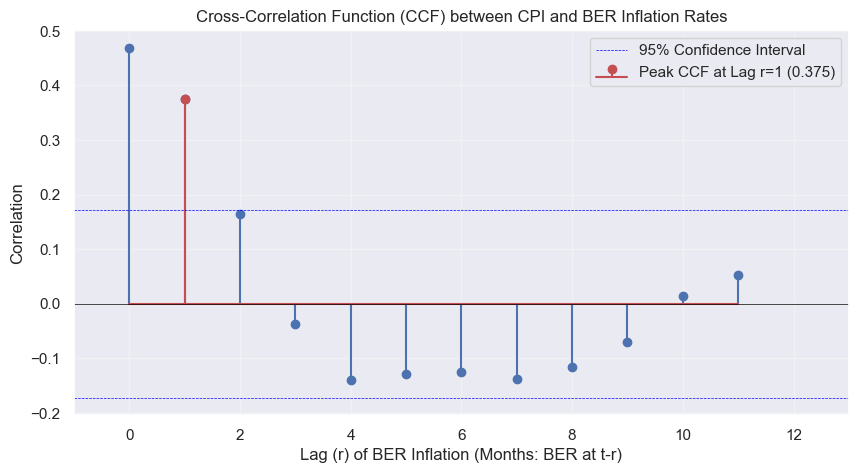

## 📌 CCF Analysis Result:
The lag 'r' for BER inflation (Y_t-r) is determined by the peak correlation.
Optimal Lag (r): 1 months (Correlation: 0.375)
----------------------------------------------------------------------


In [40]:
from statsmodels.tsa.stattools import ccf



# Align the two series based on their common time index
full_data = pd.DataFrame({'CPI_Inf': Monthly_rate[1:], 'BER_Inf': df_monthly}).dropna()
cpi_inflation_monthly = full_data['CPI_Inf']
ber_inflation_monthly = full_data['BER_Inf']

print(f"Aligned monthly data available from {full_data.index.min().strftime('%Y-%m')} to {full_data.index.max().strftime('%Y-%m')}")
print("-" * 70)
# --- 2. Cross-Correlation Function (CCF) to Find Lag (r) ---

# Plot the CCF between CPI Inflation (Xt) and BER Inflation (Yt)
ccf_values = ccf(cpi_inflation_monthly.values, ber_inflation_monthly.values, adjusted=False)
lags = np.arange(len(ccf_values))

# Limit to a reasonable number of lags (e.g., 24 months/2 years) for visibility
max_lags = 12
ccf_values = ccf_values[:max_lags]
lags = lags[:max_lags]

# Find the lag 'r' corresponding to the peak absolute CCF value (excluding lag 0, which is concurrent correlation)
# We look for the maximum correlation at lag r > 0
r_index = np.argmax(np.abs(ccf_values[1:])) + 1 # +1 to adjust index since we started looking from lag 1
lag_r = r_index
max_ccf = ccf_values[lag_r]

plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_values, markerfmt='o', linefmt='-')
# Highlight the peak
plt.stem([lag_r], [max_ccf], markerfmt='ro', linefmt='r-', label=f'Peak CCF at Lag r={lag_r} ({max_ccf:.3f})')
plt.axhline(0, color='black', linewidth=0.5)

# Calculate confidence interval for CCF: 2/sqrt(N) where N is series length
# A simple approximation for white noise, helpful for visualization
N = len(cpi_inflation_monthly)
conf_int = 2 / np.sqrt(N)
plt.axhline(conf_int, color='blue', linestyle='--', linewidth=0.5, label='95% Confidence Interval')
plt.axhline(-conf_int, color='blue', linestyle='--', linewidth=0.5)

plt.title('Cross-Correlation Function (CCF) between CPI and BER Inflation Rates')
plt.xlabel('Lag (r) of BER Inflation (Months: BER at t-r)')
plt.ylabel('Correlation')
plt.xlim([-1, max_lags + 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"## 📌 CCF Analysis Result:")
print(f"The lag 'r' for BER inflation (Y_t-r) is determined by the peak correlation.")
print(f"Optimal Lag (r): {lag_r} months (Correlation: {max_ccf:.3f})")
print("-" * 70)


In [94]:
# Define the critical split date for the analysis
SPLIT_DATE = '2013-09-01'
# ARIMA order for AR(1) is (p=1, d=0, q=0). We include a linear trend ('t') for fitting.
AR_ORDER = (1, 0, 0)

# --- 3. Prepare Data for ARX Model (ARIMA with Exogenous Regressor) ---

# Create the lagged BER inflation series (Y_t-r)
exog_regressor = ber_inflation_monthly.shift(lag_r).rename(f'BER_Inf_Lag_{lag_r}')

# Combine dependent variable (CPI_Inf) and regressor (Exog_Reg)
arx_data = pd.DataFrame({'CPI_Inf': cpi_inflation_monthly, 'Exog': exog_regressor}).dropna()

# Split the ARX data using the determined lag
train_data = arx_data.loc[arx_data.index < SPLIT_DATE]
validation_data = arx_data.loc[arx_data.index >= SPLIT_DATE]

# Separate CPI_Inf (endogenous) and Exog (exogenous) for training
train_cpi = train_data['CPI_Inf']
train_exog = train_data['Exog']

# Separate CPI_Inf (endogenous) and Exog (exogenous) for validation
validation_cpi = validation_data['CPI_Inf']
validation_exog = validation_data['Exog']

print(f"Training data size after lagging BER: {len(train_cpi)} points.")
print(f"Validation data size: {len(validation_cpi)} points.")
print("-" * 70)


# --- 4. Model Fitting (AR(1) with Exogenous Regressor) ---

print(f"Fitting ARX model: ARIMA{AR_ORDER} for CPI_Inf with BER_Inf_Lag_{lag_r} as Exogenous Regressor...")
# Use the 't' trend to include the linear time trend (similar to previous tasks)
# The SARIMAX class is often used for ARX/ARIMA with exogenous variables, but ARIMA(exog=...) 
# is simpler and sufficient for this specific AR(1) case.
model_arx = ARIMA(train_cpi, order=AR_ORDER, exog=train_exog, trend='t')
model_fit_arx = model_arx.fit()

print("Model Fitting Complete.")
print("## 📝 Description of the Final ARX Model (Coefficients and Structure):")
# The summary table shows coefficients for const, trend, ar.L1, and the exogenous variable ('Exog')
print(model_fit_arx.summary().tables[1]) 
print("-" * 70)


Training data size after lagging BER: 60 points.
Validation data size: 74 points.
----------------------------------------------------------------------
Fitting ARX model: ARIMA(1, 0, 0) for CPI_Inf with BER_Inf_Lag_1 as Exogenous Regressor...
Model Fitting Complete.
## 📝 Description of the Final ARX Model (Coefficients and Structure):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift       9.611e-06   7.25e-05      0.133      0.894      -0.000       0.000
Exog           0.0005      0.001      0.459      0.646      -0.002       0.003
ar.L1          0.5215      0.080      6.483      0.000       0.364       0.679
sigma2      1.398e-05    1.9e-06      7.347      0.000    1.03e-05    1.77e-05
----------------------------------------------------------------------


D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\879355053.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat = model.forecast(steps=1, exog=data)[0]
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\879355053.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as la

## ✅ Root Mean Squared Prediction Error (MSPE) for ARX Model:
RMSPE: 0.002372
----------------------------------------------------------------------


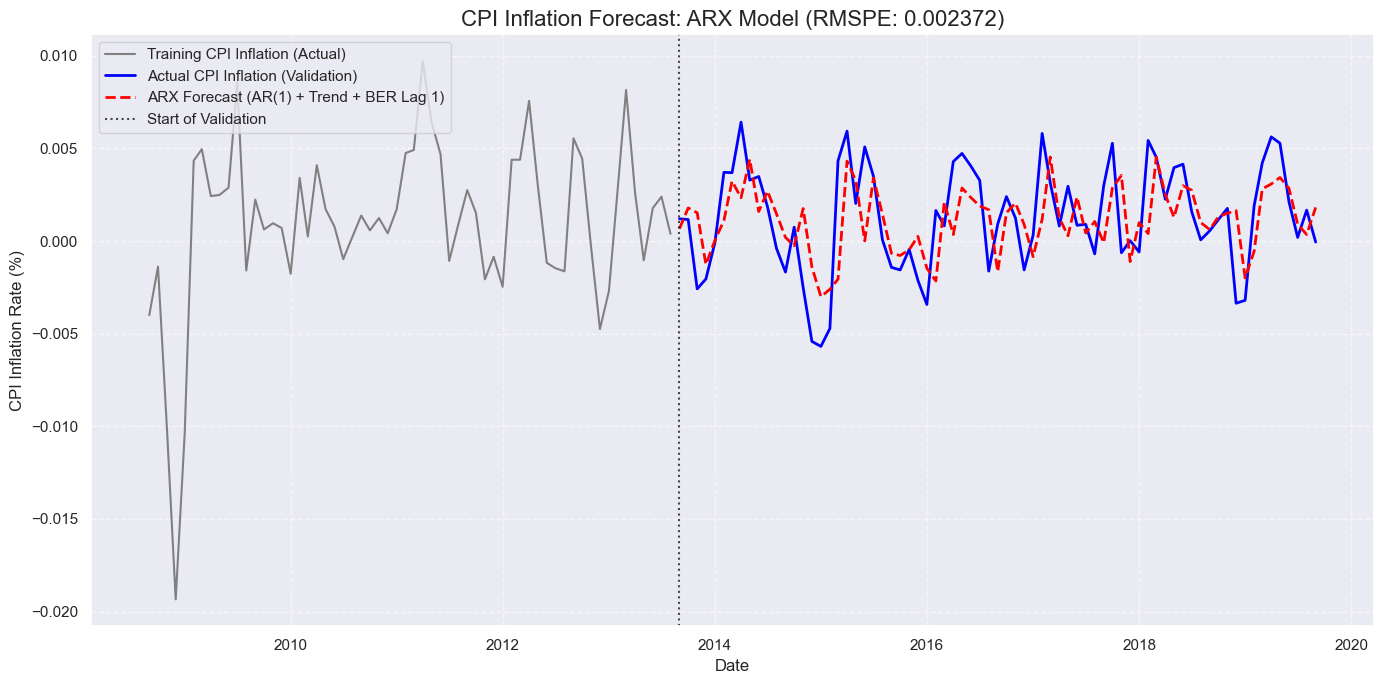

In [42]:

# --- 5. 1-Month-Ahead Forecasts (Rolling Prediction on Validation Set) ---

# The ARIMA model requires the future values of the exogenous variable (BER inflation lag)
# for the prediction steps, which we have in validation_exog.

forecasts = []

for i, date in enumerate(validation_cpi.index[:-1]): 
    # Use all data before the forecast month
    y_sub = arx_data['CPI_Inf'][arx_data['CPI_Inf'].index < date]
    y_exog = arx_data['Exog'][arx_data['Exog'].index < date]

    # Fit ARIMA(1,0,0) with linear trend and exogenous 
    model = ARIMA(y_sub, order=(2,0,0), exog= y_exog, trend='t').fit()

    # The future date to forecast (this date exists because we loop up to the second to last element)
    Future_date = validation_cpi.index[i + 1] # Get the next date in the index
    
    # Get the exogenous data for the future date
    data = validation_exog.loc[Future_date].reshape(-1,1) # forcast/predict only accepts 2d array/ dataframe exog

    # Forecast 1-step ahead
    y_hat = model.forecast(steps=1, exog=data)[0]
    forecasts.append(y_hat)

forecast_series = pd.Series(forecasts, index=validation_cpi.index[:-1])


# Align the actual validation data with the forecasts
forecast_arx_df = pd.DataFrame({
    'Actual CPI Inflation': validation_cpi, 
    'ARX Forecast': forecast_series
}).dropna()

# Calculate MSPE for evaluation
mspe_arx = mean_squared_error(forecast_arx_df['Actual CPI Inflation'], forecast_arx_df['ARX Forecast'])
print(f"## ✅ Root Mean Squared Prediction Error (MSPE) for ARX Model:")
print(f"RMSPE: {np.sqrt(mspe_arx):.6f}")
print("-" * 70)


# --- 6. Plotting Results (Overlay Predictions on Data) ---

plt.figure(figsize=(14, 7))

# Plot Training Data (Original Monthly Inflation Rates)
plt.plot(train_cpi.index, train_cpi.values, 
         label='Training CPI Inflation (Actual)', color='gray', linestyle='-')

# Plot Validation Data (Actual CPI Inflation Rates)
plt.plot(forecast_arx_df.index, forecast_arx_df['Actual CPI Inflation'], 
         label='Actual CPI Inflation (Validation)', color='blue', linewidth=2)

# Plot Forecasts (Predictions)
plt.plot(forecast_arx_df.index, forecast_arx_df['ARX Forecast'], 
         label=f'ARX Forecast (AR(1) + Trend + BER Lag {lag_r})', color='red', linestyle='--', linewidth=2)

# Formatting
plt.title(f'CPI Inflation Forecast: ARX Model (RMSPE: {np.sqrt(mspe_arx):.6f})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CPI Inflation Rate (%)', fontsize=12)
plt.axvline(pd.to_datetime(SPLIT_DATE), color='black', linestyle=':', alpha=0.7, label='Start of Validation')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('1 month_ARX.png')
plt.show()


Best lag r from CCF: 0


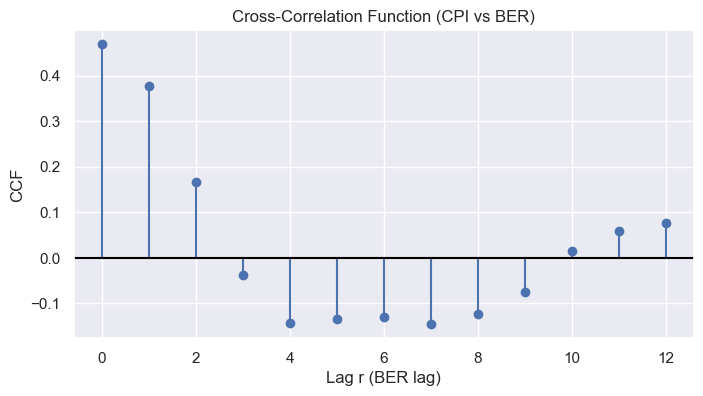

Best AR order p: 1
                            AutoReg Model Results                             
Dep. Variable:                    cpi   No. Observations:                   61
Model:                   AutoReg-X(1)   Log Likelihood                 253.631
Method:               Conditional MLE   S.D. of innovations              0.004
Date:                Tue, 18 Nov 2025   AIC                           -499.262
Time:                        19:37:54   BIC                           -490.884
Sample:                    09-01-2008   HQIC                          -495.985
                         - 08-01-2013                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0071      0.002     -3.265      0.001      -0.011      -0.003
cpi.L1         0.3003      0.117      2.571      0.010       0.071       0.529
ber_lag        0.0039      0.001 

  0%|                                                                                           | 0/74 [00:00<?, ?it/s]C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\317061237.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = model.predict(
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\317061237.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = model.predict(
C:\Users\Vikihyaat Ahlawat\AppData\Local\Temp\ipykernel_10908\317061237.py:112: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be trea


1-month ahead RMSE: 0.0024788432853100678


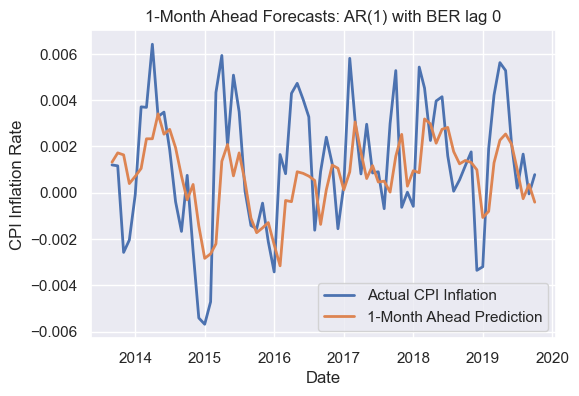

In [92]:
# More structured way to perform last three cells

from tqdm import tqdm

# ============================================================
# 1. Load your CPI and BER inflation rate series
# ============================================================

# cpi: monthly CPI inflation, pd.Series
# ber: monthly BER inflation, pd.Series

# Ensure aligned monthly data
df = pd.concat([Monthly_rate[1:], df_monthly], axis=1).dropna()
df.columns = ['cpi', 'ber']

# ============================================================
# 2. Compute Cross-Correlation Function (CCF) for r >= 0
# ============================================================

# Normalize
cpi_z = (df['cpi'] - df['cpi'].mean()) / df['cpi'].std()
ber_z = (df['ber'] - df['ber'].mean()) / df['ber'].std()

# Compute CCF for, say, 12 lags
lags = 12
ccf_vals = ccf(cpi_z, ber_z)[:lags+1]

# Find r = lag with highest correlation
r_best = np.argmax(np.abs(ccf_vals))   # largest magnitude peak
print("Best lag r from CCF:", r_best)

# Plot CCF
plt.figure(figsize=(8,4))
plt.stem(range(lags+1), ccf_vals)
plt.axhline(0, color='black')
plt.title("Cross-Correlation Function (CPI vs BER)")
plt.xlabel("Lag r (BER lag)")
plt.ylabel("CCF")
plt.show()

# ============================================================
# 3. Prepare the external regressor Y_{t-r}
# ============================================================

df['ber_lag'] = df['ber'].shift(r_best)
data = df.dropna()

y = data['cpi']
X = data[['ber_lag']]

# Add constant for ARX regression
X = sm.add_constant(X)

# ============================================================
# 4. Select AR(p) order using AIC on TRAINING data only
# ============================================================

train_end = '2013-09'   # <---- replace with your validation split date
y_train = y[y.index < train_end]
X_train = X[X.index < train_end]

max_p = 6
best_aic = np.inf
best_p = 1
best_model = None

for p in range(1, max_p+1):
    try:
        model = sm.tsa.AutoReg(
            y_train,
            lags=p,
            exog=X_train[['ber_lag']],trend='c',
            old_names=False
        ).fit()
        
        if model.aic < best_aic:
            best_aic = model.aic
            best_p = p
            best_model = model
    except:
        pass

print("Best AR order p:", best_p)
print(best_model.summary())

# ============================================================
# 5. Rolling 1-month-ahead forecast on validation set
# ============================================================

y_val = y[y.index >= train_end]
X_val = X[X.index >= train_end]

preds = []
actuals = []
dates = y_val.index

for date in tqdm(dates):
    
    y_train_roll = y[y.index < date]
    X_train_roll = X[X.index < date]

    # Fit ARX model for each rolling period
    model = sm.tsa.AutoReg(
        y_train_roll,
        lags=best_p,
        exog=X_train_roll[['ber_lag']],
        old_names=False
    ).fit()

    # Forecast 1-step ahead
    X_fore = X.loc[[date]][['ber_lag']]
    pred = model.predict(
        start=len(y_train_roll),
        end=len(y_train_roll),
        exog_oos=X_fore
    )[0]

    preds.append(pred)
    actuals.append(y.loc[date])

# Convert to series
preds = pd.Series(preds, index=dates, name='prediction')
actuals = pd.Series(actuals, index=dates, name='actual')

# Compute RMSE
rmse = np.sqrt(np.mean((preds - actuals)**2))
print("\n1-month ahead RMSE:", rmse)

# ============================================================
# 6. Plot predictions vs actual CPI
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(actuals, label='Actual CPI Inflation', linewidth=2)
plt.plot(preds, label='1-Month Ahead Prediction', linewidth=2)
plt.title("1-Month Ahead Forecasts: AR({}) with BER lag {}".format(best_p, r_best))
plt.xlabel("Date")
plt.ylabel("CPI Inflation Rate")
plt.legend()
plt.grid(True)
plt.show()


In [44]:


# ============================================================
# 1. Prepare Data: CPI (endogenous) + BER regressors (exogenous)
# ============================================================

# Assume you already have: 
# cpi_series: monthly CPI or inflation series
# ber_series: monthly data or daily BER data already aggregated monthly

# Create BER lags
exog = pd.DataFrame({
    'BER_0': df_monthly,
    'BER_1': df_monthly.shift(1)
})

# Align with CPI
data = pd.concat([Monthly_rate[1:], exog], axis=1).dropna()
data.columns = ['cpi', 'BER_0','BER_1']
y = data['cpi']
X = data[['BER_0', 'BER_1']]

# Train / validation split (same as your Part III)
train_end_date = '2013-09'   # <---- PUT YOUR DATE HERE
y_train_full = y[y.index < train_end_date]
X_train_full = X[X.index < train_end_date]

y_val = y[y.index >= train_end_date]
X_val = X[X.index >= train_end_date]

# ============================================================
# 2. Define Candidate SARIMAX Models to Try
# ============================================================

model_candidates = [
    # (p, d, q, P, D, Q)
    (1,0,1, 1,0,1),
    (1,0,1, 1,1,1),
    (1,0,1, 1,0,0),
    (1,0,1, 0,0,1),
    (1,0,1, 0,1,1),
    (1,0,1, 0,1,0),
]

# ============================================================
# 3. Rolling Forecast Function
# ============================================================

def rolling_rmse(order, seasonal_order):
    preds = []
    actuals = []

    for date in y_val.index:
        # Rolling training set up to this date
        y_train = y[y.index < date]
        X_train = X[X.index < date]

        # Fit SARIMAX
        model = sm.tsa.statespace.SARIMAX(
            y_train, 
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            trend='t',
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)

        # Exogenous value for this forecast date
        X_fore = X.loc[[date]]

        # Forecast 1 step
        f = results.get_forecast(steps=1, exog=X_fore).predicted_mean.iloc[0]

        preds.append(f)
        actuals.append(y.loc[date])

    # Compute RMSE
    preds = np.array(preds)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((actuals - preds)**2))
    
    return rmse

# ============================================================
# 4. Evaluate All Candidate Models
# ============================================================

results_list = []

for (p,d,q,P,D,Q) in tqdm(model_candidates):
    order = (p,d,q)
    seasonal = (P,D,Q,12)

    rmse = rolling_rmse(order, seasonal)
    results_list.append({
        'order': order,
        'seasonal_order': seasonal,
        'RMSE': rmse
    })

# Convert to DataFrame for easier viewing
results_df = pd.DataFrame(results_list).sort_values('RMSE')
print("=== Model Comparison (sorted by RMSE) ===")
print(results_df)

# ============================================================
# 5. Extract the Best Model
# ============================================================

best = results_df.iloc[0]
best_order = tuple(best['order'])
best_seasonal = tuple(best['seasonal_order'])

print("\nBest Model:")
print("Order:", best_order)
print("Seasonal Order:", best_seasonal)
print("RMSE:", best['RMSE'])

# ============================================================
# 6. Fit the Best Model Once on Full Training Data
# ============================================================

best_model_full = sm.tsa.statespace.SARIMAX(
    y_train_full,
    exog=X_train_full,
    order=best_order,
    seasonal_order=best_seasonal,
    trend='t',
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_results = best_model_full.fit()
print("\nBest Model Summary:")
print(best_results.summary())


  0%|                                                                                            | 0/6 [00:00<?, ?it/s]D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\sta

=== Model Comparison (sorted by RMSE) ===
       order seasonal_order      RMSE
0  (1, 0, 1)  (1, 0, 1, 12)  0.002127
2  (1, 0, 1)  (1, 0, 0, 12)  0.002236
3  (1, 0, 1)  (0, 0, 1, 12)  0.002371
4  (1, 0, 1)  (0, 1, 1, 12)  0.002375
1  (1, 0, 1)  (1, 1, 1, 12)  0.002407
5  (1, 0, 1)  (0, 1, 0, 12)  0.002761

Best Model:
Order: (1, 0, 1)
Seasonal Order: (1, 0, 1, 12)
RMSE: 0.00212652567600501

Best Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                                cpi   No. Observations:                   61
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 200.970
Date:                            Tue, 18 Nov 2025   AIC                           -385.939
Time:                                    18:27:29   BIC                           -371.138
Sample:                                08-01-2008   HQIC                          -380.369
                                     - 

D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
 

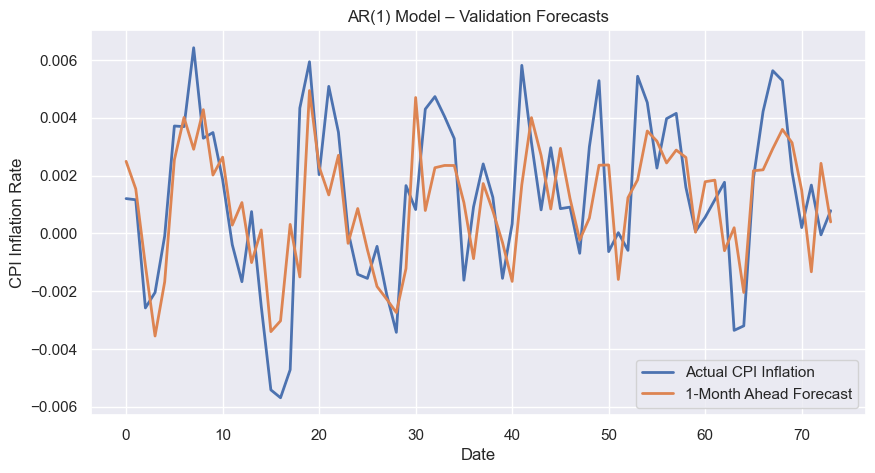

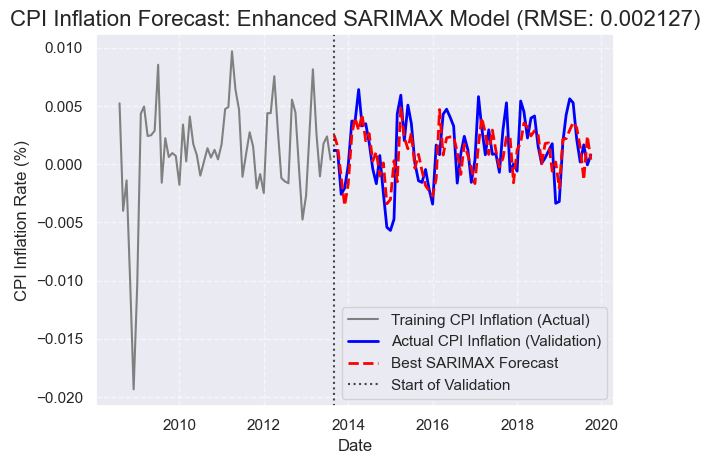

In [45]:
preds = []
actuals = []
order= best_order
seasonal_order = best_seasonal
for date in y_val.index:
        # Rolling training set up to this date
        y_train = y[y.index < date]
        X_train = X[X.index < date]

        # Fit SARIMAX
        model = sm.tsa.statespace.SARIMAX(
            y_train, 
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            trend='t',
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)

        # Exogenous value for this forecast date
        X_fore = X.loc[[date]]

        # Forecast 1 step
        f = results.get_forecast(steps=1, exog=X_fore).predicted_mean.iloc[0]

        preds.append(f)
        actuals.append(y.loc[date])



plt.figure(figsize=(10,5))
plt.plot(actuals, label="Actual CPI Inflation", linewidth=2)
plt.plot(preds, label="1-Month Ahead Forecast", linewidth=2)
plt.title(f"AR({best_p}) Model – Validation Forecasts")
plt.xlabel("Date")
plt.ylabel("CPI Inflation Rate")
plt.legend()
plt.grid(True)
plt.show()

 # Plot Training Data (Original Monthly Inflation Rates)
plt.plot(y_train_full.index, y_train_full.values, 
             label='Training CPI Inflation (Actual)', color='gray', linestyle='-')


# Plot Validation Data (Actual CPI Inflation Rates)
plt.plot(y_val.index, y_val.values, 
             label='Actual CPI Inflation (Validation)', color='blue', linewidth=2)

    # Plot Forecasts (Predictions)
plt.plot(y_val.index,preds, 
             label=f'Best SARIMAX Forecast', color='red', linestyle='--', linewidth=2)

    # Formatting
plt.title(f'CPI Inflation Forecast: Enhanced SARIMAX Model (RMSE: {best['RMSE']:.6f})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CPI Inflation Rate (%)', fontsize=12)
plt.axvline(pd.to_datetime(train_end_date), color='black', linestyle=':', alpha=0.7, label='Start of Validation')
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Final sarimax.png')